<a href="https://colab.research.google.com/github/varshamqa/AutomateBrowserSerVSC-M1/blob/master/AI_ML_K_ClusterAlgo_Varsha.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

In [8]:
df=pd.read_csv('/content/Mall_Customers.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [10]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [11]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


<Axes: xlabel='Annual Income (k$)', ylabel='Count'>

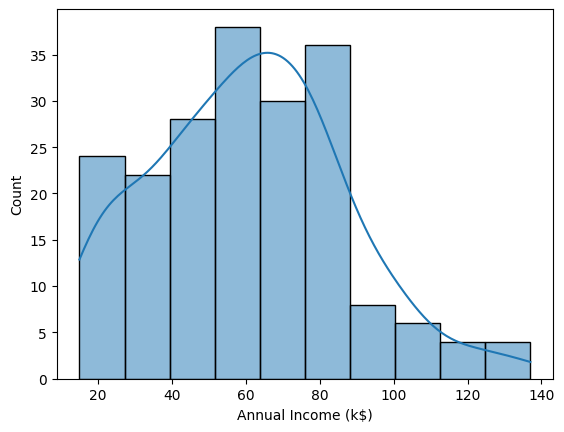

In [12]:
sns.histplot(df['Annual Income (k$)'], kde=True)

<Axes: ylabel='Annual Income (k$)'>

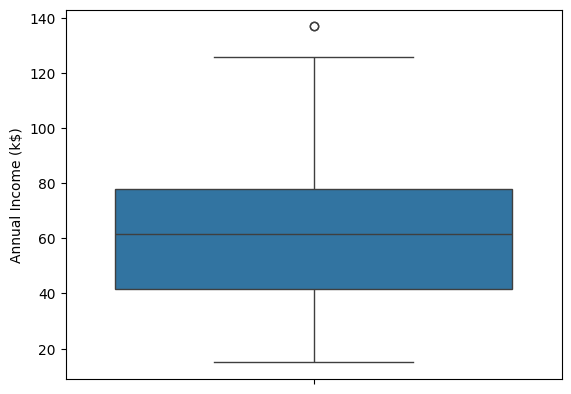

In [14]:
sns.boxplot(df['Annual Income (k$)'])

In [19]:
Q1=df['Annual Income (k$)'].quantile(0.25)
Q3=df['Annual Income (k$)'].quantile(0.75)
IQR=Q3-Q1
lower_limit=Q1-1.5*IQR
upper_limit=Q3+1.5*IQR
df=df[(df['Annual Income (k$)']>=lower_limit) &
      (df['Annual Income (k$)']<=upper_limit)]

In [24]:
df = df[['Age',
       'Annual Income (k$)',
       'Spending Score (1-100)']]


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [29]:
wcss=[]
for i in range(1,11):
  kmeans=KMeans(n_clusters=i,init='k-means++',random_state=42)
  kmeans.fit(df_scaled)
  wcss.append(kmeans.inertia_)
print(wcss)

[593.9999999999997, 385.28045294960316, 300.6077877607213, 202.69707701808613, 166.28024557954498, 129.14070006897126, 115.59946244047221, 98.95467440708106, 87.4232911350288, 79.50243415038143]


In [30]:
wcss = []

for i in range(1, 11):
    km = KMeans(n_clusters=i)
    km.fit_predict(X_scaled)
    wcss.append(km.inertia_)

print(wcss)

[593.9999999999997, 385.28045294960316, 291.6908730508621, 246.62745420930884, 164.2875973976333, 129.20637218682342, 137.32388859001048, 108.04067353185108, 90.72703113722301, 80.86196657574162]


In [31]:
km.inertia_

80.86196657574162

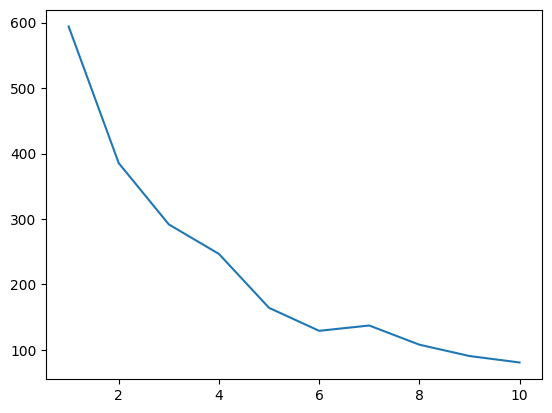

In [32]:
plt.plot(range(1,11),wcss)

In [33]:
km = KMeans(
    n_clusters=7,
    init='k-means++',
    n_init=10,
    random_state=42
)

In [34]:
y_means = km.fit_predict(X_scaled)

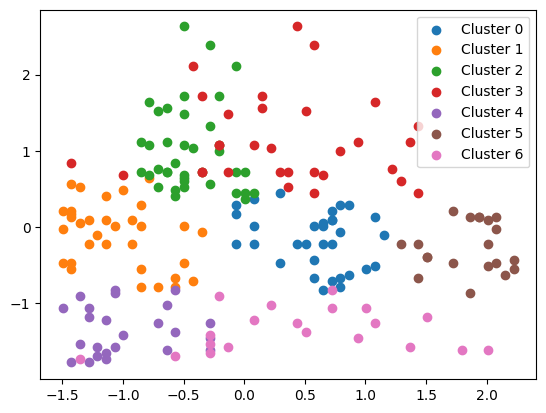

In [35]:
for i in range(km.n_clusters):
    plt.scatter(
        X_scaled[y_means == i, 0],
        X_scaled[y_means == i, 1],
        label=f'Cluster {i}'
    )

plt.legend()
plt.show()

In [36]:
from sklearn.metrics import silhouette_score

score = silhouette_score(
    X_scaled,
    y_means
)

print(score)

0.4243451604492532


In [37]:
df['Cluster'] = y_means

df.groupby('Cluster').mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,47.093750,55.562500,47.812500
1,24.242424,57.363636,46.606061
2,32.763158,85.210526,82.105263
3,43.387097,88.161290,17.322581
4,25.250000,25.833333,76.916667
5,64.850000,53.150000,49.850000
6,45.400000,25.650000,18.550000


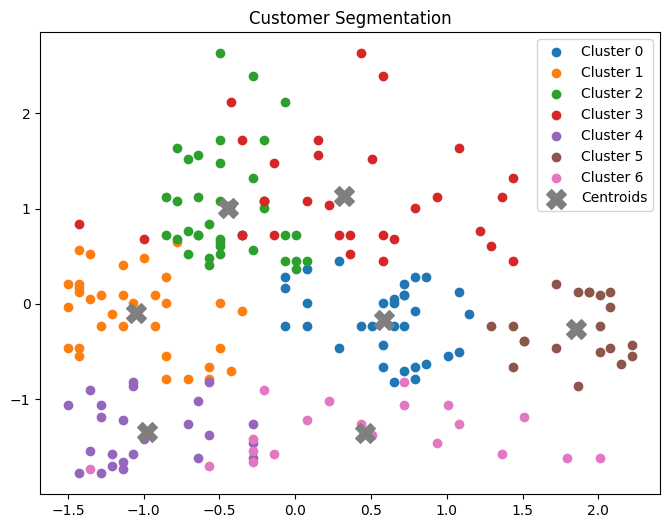

In [38]:
plt.figure(figsize=(8,6))

for i in range(km.n_clusters):
    plt.scatter(
        X_scaled[y_means == i,0],
        X_scaled[y_means == i,1],
        label=f'Cluster {i}'
    )

plt.scatter(
    km.cluster_centers_[:,0],
    km.cluster_centers_[:,1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.legend()
plt.title('Customer Segmentation')
plt.show()

In [39]:
df['Cluster'] = y_means

df.groupby('Cluster').mean()

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,47.093750,55.562500,47.812500
1,24.242424,57.363636,46.606061
2,32.763158,85.210526,82.105263
3,43.387097,88.161290,17.322581
4,25.250000,25.833333,76.916667
5,64.850000,53.150000,49.850000
6,45.400000,25.650000,18.550000
